# Práctica evaluación módulo 'Machine Learning y Deep Learning

## 0. Configuración Notebook

### Importación librerías

In [5]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import plotly.express as px
import plotly.graph_objects as go
import seaborn as sns
import xgboost as xgb
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from matplotlib.colors import ListedColormap, LinearSegmentedColormap
from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import GridSearchCV, StratifiedKFold
from sklearn.pipeline import Pipeline
from sklearn.metrics import accuracy_score, recall_score, precision_score, f1_score, roc_auc_score
from sklearn.metrics import classification_report, RocCurveDisplay, ConfusionMatrixDisplay

### Definición constantes

In [6]:
DATA_DIR_RAW = '../../data/raw'

In [7]:
DATASET = f'{DATA_DIR_RAW}/dataset_practica_final.csv'
DATASET

'../../data/raw/dataset_practica_final.csv'

### Definición funciones

In [10]:
def compare_scores(model_list, y_test, X_test):
    '''
    muestra un dataframe con índice por modelo y columnas por métrica, valores el valor de la métrica
    '''
    pass

In [5]:
def plot_ROC(model_list, y_test, X_test):
    '''
    saca una figura con un subplot por modelo del ROC
    '''
    pass

In [6]:
def plot_confusion_matrix(model_list, y_test, X_test):
    '''
    saca una figura con un subplot por modelo de la confusion_matrix
    '''
    pass

## 1. Carga y pre-procesamiento de datos

### Carga y copia

In [21]:
df = pd.read_csv(DATASET)
df_cp = df.copy()

In [22]:
df_cp.head()

,hotel,is_canceled,lead_time,arrival_date_year,arrival_date_month,arrival_date_week_number,arrival_date_day_of_month,stays_in_weekend_nights,stays_in_week_nights,adults,...,deposit_type,agent,company,days_in_waiting_list,customer_type,adr,required_car_parking_spaces,total_of_special_requests,reservation_status,reservation_status_date
0,Resort Hotel,0,342,2015,July,27,1,0,0,2,...,No Deposit,NaN,NaN,0,Transient,0.0,0,0,Check-Out,2015-07-01
1,Resort Hotel,0,737,2015,July,27,1,0,0,2,...,No Deposit,NaN,NaN,0,Transient,0.0,0,0,Check-Out,2015-07-01
2,Resort Hotel,0,7,2015,July,27,1,0,1,1,...,No Deposit,NaN,NaN,0,Transient,75.0,0,0,Check-Out,2015-07-02
3,Resort Hotel,0,13,2015,July,27,1,0,1,1,...,No Deposit,304.0,NaN,0,Transient,75.0,0,0,Check-Out,2015-07-02
4,Resort Hotel,0,14,2015,July,27,1,0,2,2,...,No Deposit,240.0,NaN,0,Transient,98.0,0,1,Check-Out,2015-07-03


### Inspección

## Variables

| Nombre Variable                  | Descripción                                              |
| -------------------------------- | -------------------------------------------------------- |
| `hotel`                          | Tipo de hotel: City Hotel o Resort Hotel                 |
| `is_canceled`                    | Variable objetivo: 1 si fue cancelado, 0 si no           |
| `lead_time`                      | Días entre la reserva y la fecha de llegada              |
| `arrival_date_year`              | Año de llegada                                           |
| `arrival_date_month`             | Mes de llegada                                           |
| `arrival_date_week_number`       | Número de la semana del año                              |
| `arrival_date_day_of_month`      | Día del mes de llegada                                   |
| `stays_in_weekend_nights`        | Noches de fin de semana reservadas                       |
| `stays_in_week_nights`           | Noches entre semana reservadas                           |
| `adults`                         | Número de adultos                                        |
| `children`                       | Número de niños                                          |
| `babies`                         | Número de bebés                                          |
| `meal`                           | Tipo de comida reservada                                 |
| `country`                        | País de origen del cliente                               |
| `market_segment`                 | Canal de marketing (online, offline, grupos...)          |
| `distribution_channel`           | Canal de distribución (directo, TA/TO...)                |
| `is_repeated_guest`              | 1 si el cliente ha estado anteriormente                  |
| `previous_cancellations`         | Nº de cancelaciones anteriores                           |
| `previous_bookings_not_canceled` | Nº de reservas previas no canceladas                     |
| `reserved_room_type`             | Tipo de habitación reservada                             |
| `assigned_room_type`             | Tipo de habitación asignada                              |
| `booking_changes`                | Nº de cambios en la reserva                              |
| `deposit_type`                   | Tipo de depósito: No Deposit, Refundable, etc.           |
| `agent`                          | ID del agente (puede ser nulo)                           |
| `company`                        | ID de la empresa (puede ser nulo)                        |
| `days_in_waiting_list`           | Días en lista de espera                                  |
| `customer_type`                  | Tipo de cliente: Transient, Group, etc.                  |
| `adr`                            | Average Daily Rate (precio promedio por noche)           |
| `required_car_parking_spaces`    | Plazas de parking solicitadas                            |
| `total_of_special_requests`      | Nº de peticiones especiales                              |
| `reservation_status`             | Estado final de la reserva: Check-Out, Canceled, No-Show |
| `reservation_status_date`        | Fecha en que se actualizó el estado                      |

In [23]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 119390 entries, 0 to 119389
Data columns (total 32 columns):
 #   Column                          Non-Null Count   Dtype  
---  ------                          --------------   -----  
 0   hotel                           119390 non-null  str    
 1   is_canceled                     119390 non-null  int64  
 2   lead_time                       119390 non-null  int64  
 3   arrival_date_year               119390 non-null  int64  
 4   arrival_date_month              119390 non-null  str    
 5   arrival_date_week_number        119390 non-null  int64  
 6   arrival_date_day_of_month       119390 non-null  int64  
 7   stays_in_weekend_nights         119390 non-null  int64  
 8   stays_in_week_nights            119390 non-null  int64  
 9   adults                          119390 non-null  int64  
 10  children                        119386 non-null  float64
 11  babies                          119390 non-null  int64  
 12  meal                       

In [24]:
df_cp.shape

(119390, 32)

In [16]:
# Tipos de datos
# 12 columnas son srt
# 16 columnas son int64
# 4 columnas son float64

In [25]:
# Valores nulos
df_cp.isna().sum()[df_cp.isna().sum() > 0]

children         4
country        488
agent        16340
company     112593
dtype: int64

In [31]:
df_cp.describe().T

,count,mean,std,min,25%,50%,75%,max
is_canceled,119390.0,0.370416,0.482918,0.00,0.00,0.000,1.0,1.0
lead_time,119390.0,104.011416,106.863097,0.00,18.00,69.000,160.0,737.0
arrival_date_year,119390.0,2016.156554,0.707476,2015.00,2016.00,2016.000,2017.0,2017.0
arrival_date_week_number,119390.0,27.165173,13.605138,1.00,16.00,28.000,38.0,53.0
arrival_date_day_of_month,119390.0,15.798241,8.780829,1.00,8.00,16.000,23.0,31.0
stays_in_weekend_nights,119390.0,0.927599,0.998613,0.00,0.00,1.000,2.0,19.0
stays_in_week_nights,119390.0,2.500302,1.908286,0.00,1.00,2.000,3.0,50.0
adults,119390.0,1.856403,0.579261,0.00,2.00,2.000,2.0,55.0
children,119386.0,0.103890,0.398561,0.00,0.00,0.000,0.0,10.0
babies,119390.0,0.007949,0.097436,0.00,0.00,0.000,0.0,10.0


In [32]:
# Elimino características directamente relacionadas con la variable objetivo

In [ ]:
# Descartar las características irrelevantes

In [33]:
df = pd.read_csv(DATASET)

In [ ]:
# reservatiobn_status está directamente ligada a is_canceled
# Nos da el valor de la variable objetivo (fuga de datos)

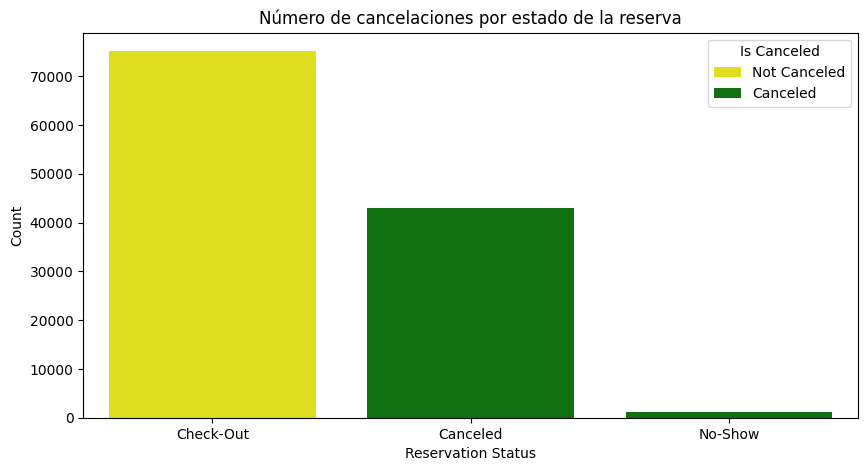

In [35]:
plt.figure(figsize=(10, 5))
sns.countplot(x='reservation_status', hue='is_canceled', data=df, palette=['yellow', 'green'])
plt.title('Número de cancelaciones por estado de la reserva')
plt.xlabel('Reservation Status')
plt.ylabel('Count')
plt.legend(title='Is Canceled', labels=['Not Canceled', 'Canceled'])
plt.show()

In [36]:
df.groupby('reservation_status')['is_canceled'].mean()

reservation_status
Canceled     1.0
Check-Out    0.0
No-Show      1.0
Name: is_canceled, dtype: float64

In [ ]:
# Todas las reservar con un reservation_status de "Canceled" o "No-Show" son efectivamente canceladas

In [37]:
# Se elimina
df = df.drop(['reservation_status'], axis=1)

In [38]:
# Lo mismo para 'reservation_status_date'
df = df.drop(['reservation_status_date'], axis=1)

In [39]:
# 'assigned_room_type' es irrelevante porque se asigna después de hacer la reserva. No se puede usar para predecir
df = df.drop(['assigned_room_type'], axis=1)

In [96]:
#'arrival_date_year' Solo incluye algunos años. Haría sesgar el modelo a años específicos
df['arrival_date_year'].value_counts()

KeyError: 'arrival_date_year'

In [40]:
df['arrival_date_year'].value_counts()

arrival_date_year
2016    56707
2017    40687
2015    21996
Name: count, dtype: int64

In [97]:
df['assigned_room_type'].value_counts()

KeyError: 'assigned_room_type'

In [42]:
df = df.drop(['arrival_date_year'], axis=1)

In [44]:
# Ver la cardinalidad de diferentes columnas
alta_cardinalidad = ['country', 'agent', 'company']

In [45]:
unicas_categorias = df[alta_cardinalidad].nunique()
valores_faltantes = df[alta_cardinalidad].isnull().sum()

alta_cardinalidad_df = pd.DataFrame({'Unicas_Categorias': unicas_categorias,'Valores_Faltantes': valores_faltantes})

alta_cardinalidad_df

,Unicas_Categorias,Valores_Faltantes
country,177,488
agent,333,16340
company,352,112593


In [55]:
top_countries = df['country'].value_counts().nlargest(10).index
df['country'] = df['country'].where(df['country'].isin(top_countries), 'Other')

In [56]:
# Simplificar Agente y Compañía a variables binarias
df['has_company'] = df['company'].notnull().astype(int)
df['has_agent'] = df['agent'].notnull().astype(int)
df.drop(['company', 'agent'], axis=1, inplace=True)

KeyError: 'company'

In [62]:
# Calcular el porcentaje de valores faltantes en el conjunto de datos original
missing_values_percentage = (df.isnull().sum() / len(df)) * 100
missing_values_percentage[missing_values_percentage > 0]

Series([], dtype: float64)

In [59]:
df['children'].value_counts()

children
0.0     110796
1.0       4861
2.0       3652
3.0         76
10.0         1
Name: count, dtype: int64

In [60]:
df['children'] = df['children'].fillna(df['children'].median())

In [61]:
df['children'].value_counts()

children
0.0     110800
1.0       4861
2.0       3652
3.0         76
10.0         1
Name: count, dtype: int64

In [77]:
datos_ruidosos = {
    'adr': df[df['adr'] < 0],
    'adults': df[df['adults'] == 0],
    'children': df[df['children'] == 10],
    'babies': df[df['babies'] == 10]
}

datos_ruidosos = {key: len(value) for key, value in noisy_data.items()}
datos_ruidosos

{'adr': 1, 'adults': 403, 'children': 1, 'babies': 1}

In [78]:
# Hay 1 reserva con una Tasa Diaria Promedio (ADR) negativa. No tiene sentido
# Hay 403 reservas con 0 adultos
# Hay 1 reserva con 10 niños
# Hay 1 reserva con 1 bebe

In [79]:
# Reemplazar el valor negativo por la mediana
df.loc[df['adr'] < 0, 'adr'] = df['adr'].median()

In [80]:
# Eliminar las columnas con 0 adultos
df = df[df['adults'] != 0]

In [81]:
# Eliminar las filas con 10 niños y 10 bebes
df = df[df['children'] != 10]
df = df[df['babies'] != 10]

In [82]:
datos_ruidosos_modificados = {
    'adr': df[df['adr'] < 0],
    'adults': df[df['adults'] == 0],
    'children': df[df['children'] == 10],
    'babies': df[df['babies'] == 10]
}

numero_datos_ruidosos_modificados = {key: len(value) for key, value in datos_ruidosos_modificados.items()}
numero_datos_ruidosos_modificados

{'adr': 0, 'adults': 0, 'children': 0, 'babies': 0}

In [83]:
df.dtypes

hotel                                 str
is_canceled                         int64
lead_time                           int64
arrival_date_month                    str
arrival_date_week_number            int64
arrival_date_day_of_month           int64
stays_in_weekend_nights             int64
stays_in_week_nights                int64
adults                              int64
children                          float64
babies                              int64
meal                                  str
country                               str
market_segment                        str
distribution_channel                  str
is_repeated_guest                   int64
previous_cancellations              int64
previous_bookings_not_canceled      int64
reserved_room_type                    str
booking_changes                     int64
deposit_type                          str
days_in_waiting_list                int64
customer_type                         str
adr                               

In [93]:
#Balanceamiento de is_canceled
df['is_canceled'].value_counts(normalize=True) * 100

is_canceled
0    62.924738
1    37.075262
Name: proportion, dtype: float64

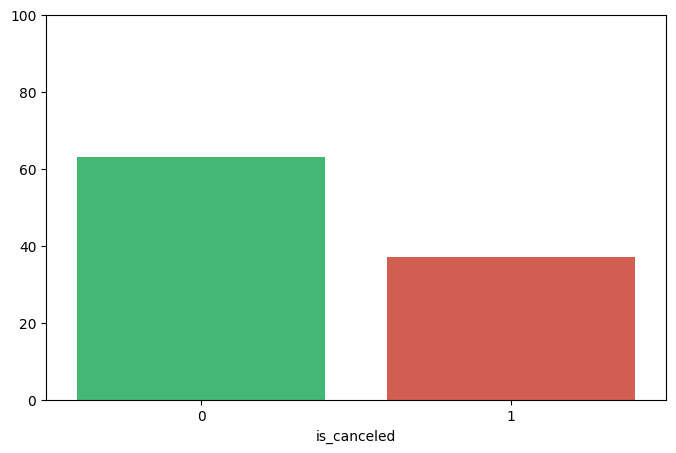

In [91]:
#Balanceamiento de is_canceled
porcentajes = df['is_canceled'].value_counts(normalize=True) * 100

# Tamaño
plt.figure(figsize=(8, 5))

#Gráfico de barras
ax = sns.barplot(
    x=porcentajes.index, 
    y=porcentajes.values, 
    palette=['#2ecc71', '#e74c3c'],
    hue=porcentajes.index,
    legend=False
)

plt.ylim(0, 100)

plt.show()

In [95]:
# El 37.07% de las reservas fueron canceladas
# El 62.92% no fueron canceladas

# Hay un poco de balanceo, de desequilibrio en el target. Pero no muy desequilibrado.
# No hay que aplicar técnicas de muestreo

In [94]:
df.info()

<class 'pandas.DataFrame'>
Index: 118985 entries, 0 to 119389
Data columns (total 28 columns):
 #   Column                          Non-Null Count   Dtype  
---  ------                          --------------   -----  
 0   hotel                           118985 non-null  str    
 1   is_canceled                     118985 non-null  int64  
 2   lead_time                       118985 non-null  int64  
 3   arrival_date_month              118985 non-null  str    
 4   arrival_date_week_number        118985 non-null  int64  
 5   arrival_date_day_of_month       118985 non-null  int64  
 6   stays_in_weekend_nights         118985 non-null  int64  
 7   stays_in_week_nights            118985 non-null  int64  
 8   adults                          118985 non-null  int64  
 9   children                        118985 non-null  float64
 10  babies                          118985 non-null  int64  
 11  meal                            118985 non-null  str    
 12  country                         

In [ ]:
def loader(dataset_csv_filename:str, OHE:bool) -> (pd.core.frame.DataFrame, pd.core.frame.DataFrame, pd.core.series.Series, pd.core.series.Series):
    '''
    dataset_csv_filename: ruta al csv con los datos
    OHE: si es true, los campos categóricos se condifican con OneHotEncoder. 
         si false los campos de texto se codifican a categoría y después a numérico usando sus códigos
    '''
    # se setea random_state para que los resultados sean predecibles (que el resultado sea el mismo siempre)
    check_random_state(42)

    # carga del csv en un dataframe
    dset = pd.read_csv(DATASET)
    
    # Eliminación de variables con fugas de datos (Data Leakage)
    columns_to_drop =[
                        'reservation_status',
                        'reservation_status_date',
                        'arrival_date_year',
                        'assigned_room_type']
    dset.drop(columns_to_drop, axis= 1, inplace=True)

    # --- LIMPIEZA DE ANOMALÍAS ---
    
    # Reemplazar el valor negativo por la mediana
    dset.loc[dset['adr'] < 0, 'adr'] = dset['adr'].median()

    # Eliminar las columnas con 0 adultos
    dset = dset[dset['adults'] != 0]

    # Eliminar las filas con 10 niños y 10 bebes
    dset = dset[dset['children'] != 10]
    dset = dset[dset['babies'] != 10]

    # --- LIMPIEZA DE ANOMALÍAS ---


    # Agrupar países con poca representación
    top_countries = dset['country'].value_counts().nlargest(10).index
    dset['country'] = dset['country'].where(dset['country'].isin(top_countries), 'Other')

    # Convertir el mes a valor numérico para mantener la temporalidad
    month_map = {'January': 1, 'February': 2, 'March': 3, 'April': 4, 'May': 5, 'June': 6,
                 'July': 7, 'August': 8, 'September': 9, 'October': 10, 'November': 11, 'December': 12}
    dset['arrival_date_month'] = dset['arrival_date_month'].map(month_map)

    # Simplificar Agente y Compañía a variables binarias
    dset['has_company'] = dset['company'].notnull().astype(int)
    dset['has_agent'] = dset['agent'].notnull().astype(int)
    dset.drop(['company', 'agent'], axis=1, inplace=True)
    
    # relleno de los valores faltantes
    dset['children'] = dset['children'].fillna(dset['children'].median())

    # separación en target (variable objetivo) y features
    y = dset['is_canceled']
    X = dset.drop(['is_canceled'], axis=1)

    # train_test_split se hace antes de trasnformar nada
    X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, stratify=y)
    

    # OneHot encoder de las variables categóricas (no ordinales) y standa
    list_one_hot_cols = []
    if OHE:
        list_one_hot_cols = [
                            'hotel',
                            'meal',
                            'country',
                            'market_segment',
                            'distribution_channel',
                            #'is_repeated_guest',
                            'reserved_room_type',
                            #'assigned_room_type',
                            'deposit_type',
                            #'agent',
                            #'company',
                            'customer_type']
    else:
        # primero se ponen en una lista los cmps de texto
        # sdespués se convierten los campos a catgorías, se toman sus códigos numéricos (.cat.codes) y se sustitye a los string originales por ellos
        # text_fields = [c for c in X.columns if X[c].dtype==object
        text_fields = [c for c in X_train.columns if X_train[c].dtype==object]
        for c in text_fields:
            X_train[c] = X_train[c].astype('category').cat.codes
            X_test[c] = X_test[c].astype('category').cat.codes  

    # Mejor hacer la lista dinámica, para que no se pierda nada
    list_numeric_cols = [col for col in X_train.columns if col not in list_one_hot_cols]

    columns_preprocessor = ColumnTransformer(transformers=[
        ('one_hot', OneHotEncoder(drop='first', sparse_output=False), list_one_hot_cols),
        #('ordinal', OrdinalEncoder(), list_ordinal_cols),
        ('numeric', MinMaxScaler(), list_numeric_cols)
    ])

    # columns_preprocessor.fit_transform(X_test)
    # fit_transform solo en train, transform en test
    X_train_processed = columns_preprocessor.fit_transform(X_train)
    X_test_processed = columns_preprocessor.transform(X_test)

    # Restaurar a DataFrame para no perder los nombres
    nombres_columnas = columns_preprocessor.get_feature_names_out()

    # Se limpia el texto que añade scikit-learn por defecto
    nombres_columnas = [nombre.replace('one_hot__', '').replace('numeric__', '') for nombre in nombres_columnas]

    X_train = pd.DataFrame(X_train_processed, columns=nombres_columnas, index=X_train.index)
    X_test = pd.DataFrame(X_test_processed, columns=nombres_columnas, index=X_test.index)

    return (X_train, X_test, y_train, y_test)

### *Cosas a ver*:
- si está balanceado
- identificar outlayers
- identificar datos faltantes
- sacar correlaciones
- sacar pca 


## 2. Entrenamiento (incluye selección de hiperparámetros)

### 2.1 Logistic Regression

### 2.2 DecisionTree

### 2.3 Random Forest

### 2.4 XGBoost

### 2.5 Multilayer Neural Network

## 3. Comparativa Modelos